# Experiment No. 2
## Exploratory Data Analysis (EDA)

### Aim
To perform Exploratory Data Analysis (EDA) on a given dataset to gain a deeper understanding of its key characteristics and relationships between variables.

### 1. Imports

The following libraries are imported for numerical operations, data manipulation, data visualization, and statistical analysis.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### 2. Loading the Dataset

The Titanic dataset is loaded using Seaborn's built-in dataset function and stored in the `titanic` variable.

In [2]:
titanic = sns.load_dataset('titanic')

### 3. Quick Look into the Dataset

These commands help us understand the structure of the dataset and view its first and last few records.

In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


The `head()` function displays the first five rows of the dataset.

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


The `tail()` function displays the last five rows of the dataset.

In [5]:
titanic.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


### 4. Summary Statistics

The `describe()` function provides statistical information such as count, mean, standard deviation, minimum, maximum, and quartiles for numerical features.

In [6]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The `transpose()` function changes rows into columns, making the statistical summary easier to read for each feature.

titanic.describe().transpose()

### 5.1 Number of Passengers Who Survived and Died

The `value_counts()` function counts the number of passengers in each survival category. Here, 0 represents passengers who did not survive and 1 represents passengers who survived.

In [7]:
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

A count plot is used to visually represent the number of passengers who survived and did not survive.

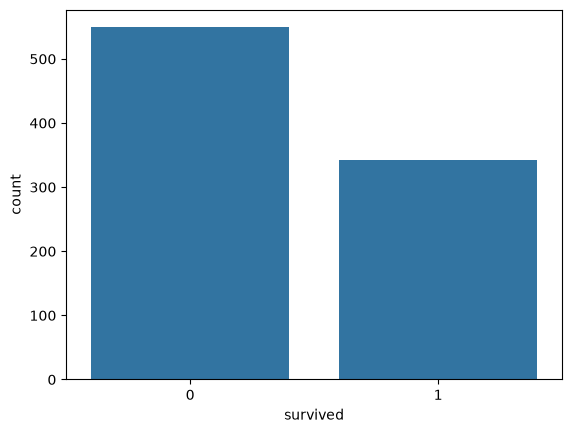

In [8]:
sns.countplot(data=titanic, x='survived')
plt.show()

### 5.2 Passenger Class

The `pclass` column represents passenger class using numerical values 1, 2, and 3. The following code counts the passengers in each class.

In [9]:
titanic['pclass'].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

The `class` column represents the same passenger classes using text values such as First, Second, and Third.

In [10]:
titanic['class'].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

The following code selects both `pclass` and `class` columns so that their values can be compared.

In [11]:
p_class = titanic[['pclass', 'class']]
p_class.head()

,pclass,class
0,3,Third
1,1,First
2,3,Third
3,1,First
4,3,Third


### 5.3 Number of Genders

The `value_counts()` function is used to find the number of male and female passengers in the dataset.

In [12]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

A count plot is used to visualize the distribution of passengers according to gender.

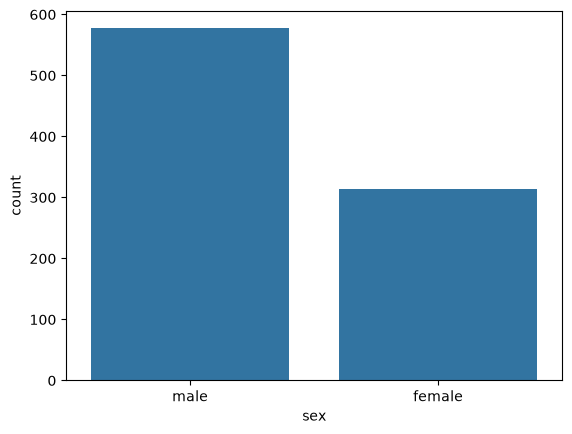

In [13]:
sns.countplot(data=titanic, x='sex')
plt.show()

### 5.4 Passengers Younger Than 20 Years

The following code filters the dataset and selects passengers whose age is less than 20 years.

In [14]:
less_than_20 = titanic[titanic['age'] < 20]
less_than_20.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
14,0,3,female,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
16,0,3,male,2.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False


The `len()` function is used to find the total number of passengers younger than 20 years.

In [15]:
len(less_than_20)

164

### 5.5 Passenger Categories

The `who` column contains passenger categories. A pie chart is used to show the proportion of each category.

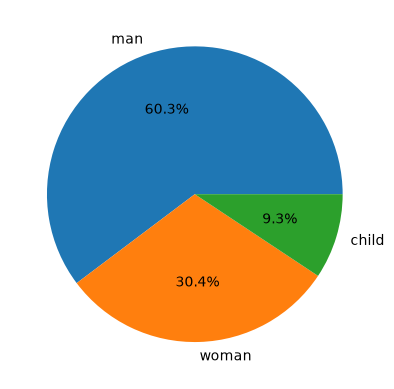

In [16]:
titanic['who'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.show()

### 5.6 Unique Embarkation Cities

The `nunique()` function is used to find the number of unique cities in the `embark_town` column.

In [17]:
titanic['embark_town'].nunique()

3

The `value_counts()` function counts the number of passengers who embarked from each city.

In [18]:
titanic['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

A bar chart is used to visualize the number of passengers from each embarkation city.

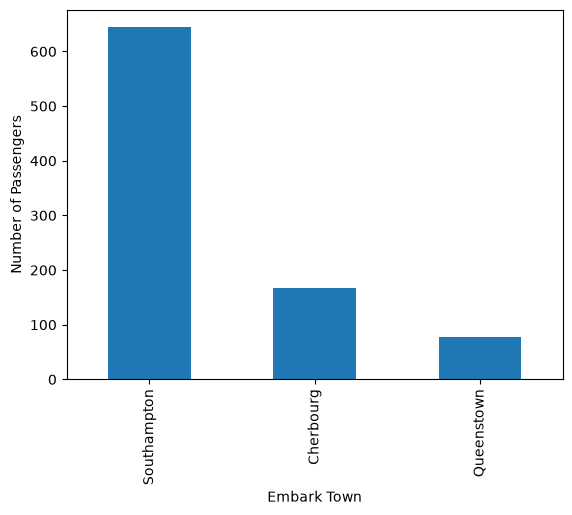

In [19]:
titanic['embark_town'].value_counts().plot(kind='bar')
plt.xlabel('Embark Town')
plt.ylabel('Number of Passengers')
plt.show()

### 6. Missing Data

The `isnull().sum()` function identifies the number of missing values present in each column of the dataset.

In [20]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

A heatmap is used to visually identify the locations of missing values in the dataset.

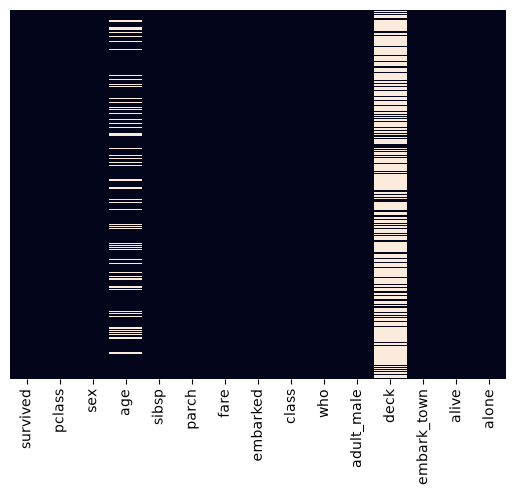

In [21]:
sns.heatmap(titanic.isnull(), yticklabels=False, cbar=False)
plt.show()

### 7.1 Survival by Gender

This count plot compares the number of passengers who survived and did not survive based on their gender.

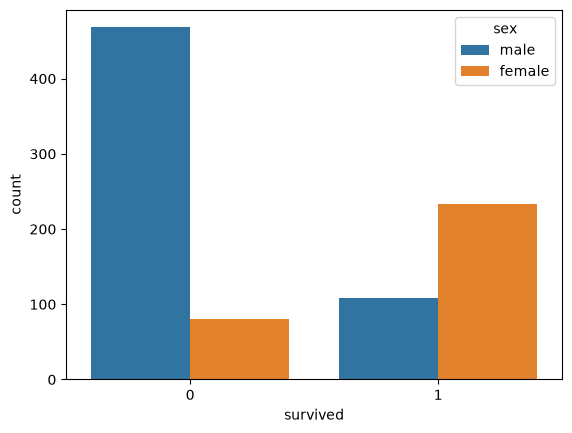

In [22]:
sns.countplot(data=titanic, x='survived', hue='sex')
plt.show()

### 7.2 Survival by Passenger Class

This count plot compares passenger survival across different passenger classes.

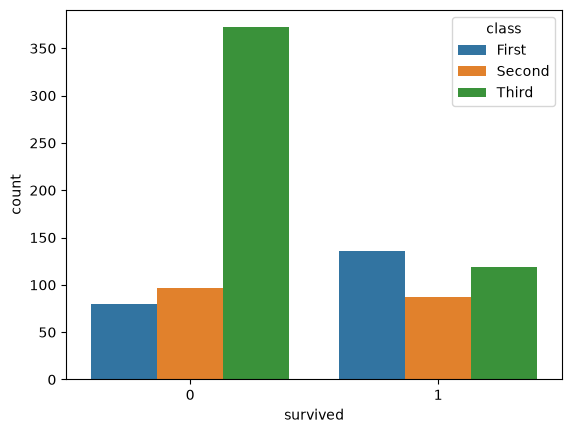

In [23]:
sns.countplot(data=titanic, x='survived', hue='class')
plt.show()

### 7.3 Age Distribution

A histogram is used to understand the distribution of passengers' ages in the Titanic dataset.

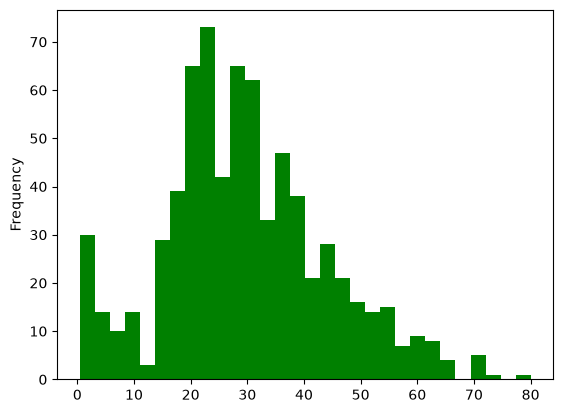

In [24]:
titanic.age.plot(kind='hist', bins=30, color='green')
plt.show()

### 7.4 Relationship Between Age and Fare

A scatter plot is used to study the relationship between passenger age and ticket fare. Different colors represent different passenger classes.

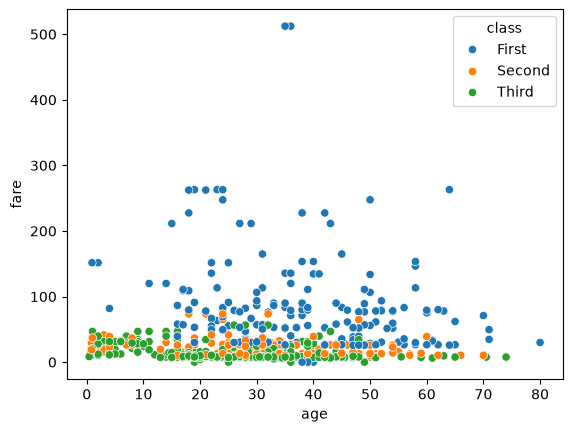

In [25]:
sns.scatterplot(data=titanic, x='age', y='fare', hue='class')
plt.show()

### 7.5 Relationship Between Age and Fare by Gender

This scatter plot shows the relationship between passenger age and fare, with different colors representing gender.

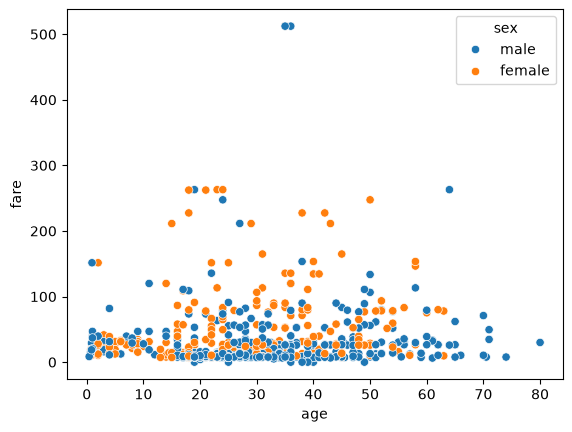

In [26]:
sns.scatterplot(data=titanic, x='age', y='fare', hue='sex')
plt.show()

## 8. Checking Correlating Features

Correlation analysis helps us understand how strongly numerical features are related to each other. It can also help identify features that contain similar information.

### 8.1 Calculate Correlation

Correlation is calculated only for numerical features because categorical text values cannot be directly used in numerical correlation calculations.

In [28]:
correlation = titanic.corr(numeric_only=True)
correlation

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


The following code displays the correlation of each numerical feature with the `survived` feature.

In [29]:
correlation['survived']

survived      1.000000
pclass       -0.338481
age          -0.077221
sibsp        -0.035322
parch         0.081629
fare          0.257307
adult_male   -0.557080
alone        -0.203367
Name: survived, dtype: float64

A heatmap is used to visualize the correlation matrix. The values show the strength and direction of the correlation between numerical features.

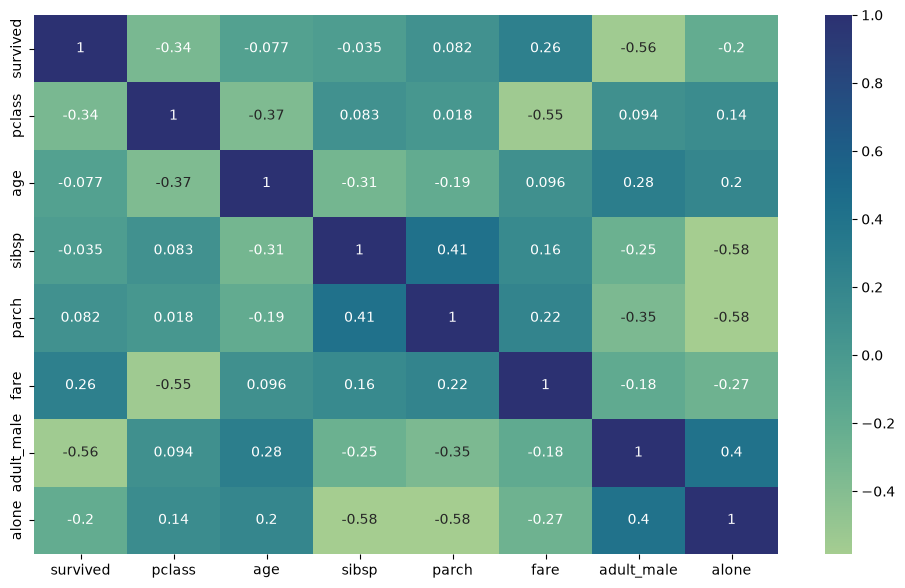

In [30]:
plt.figure(figsize=(12, 7))
sns.heatmap(correlation, annot=True, cmap='crest')
plt.show()

## Conclusion

In this practical, Exploratory Data Analysis (EDA) was performed on the Titanic dataset. Statistical summaries and different visualization techniques were used to understand the data, identify missing values, analyze distributions, and study relationships between variables. Correlation analysis was also performed to understand relationships between numerical features. The insights obtained from EDA can be useful for feature selection and further machine learning model development.